# Workshop 3 — Modelling the light curve of a variable star

## How do I determine the variability period from noisy observations?

A light curve records how an object's brightness changes with time. The measurements may be noisy and unevenly spaced because of weather, daylight, scheduling and visibility.

In this workshop you will learn how to:

- represent a simple periodic model
- generate and inspect a synthetic light curve
- fit a model to one-dimensional data
- use residuals to assess a fit
- search for an unknown period with a Lomb–Scargle periodogram
- phase-fold observations to reveal periodic behaviour

<figure style="text-align: center;">
    <img
      src="images/Cepheid.gif"
      alt="Animation of a variable star"
      width="250"
    >
    <figcaption>
        Figure 1: Animation of a pulsating Cepheid variable star (<a href="https://commons.wikimedia.org/wiki/File:Cepheid_animation_5_rend_1.gif">Merikanto</a>, <a href="https://creativecommons.org/licenses/by-sa/4.0">CC BY-SA 4.0</a>)
    </figcaption>
</figure>

## 1. Import the packages

NumPy supplies arrays and random sampling, Matplotlib makes the figures, SciPy performs least-squares fitting, and Astropy supplies the Lomb–Scargle periodogram used for unevenly sampled time-series data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
from astropy.timeseries import LombScargle

## 2. A simple model for periodic variability

We will describe the star's **relative flux** as a sinusoid:

$$
F(t) = F_0 + A\sin\left(\frac{2\pi t}{P} + \phi\right),
$$

where:

- $F_0$ is the mean relative flux
- $A$ is the semi-amplitude in relative-flux units
- $P$ is the period in days
- $\phi$ is the phase offset in radians

We normalise the flux so that its mean is close to one. Values above one indicate that the star is brighter than its mean level, making the plots intuitive to read.

In [2]:
def sinusoidal_light_curve(time, mean_flux, amplitude, period, phase):
    return mean_flux + amplitude * np.sin(
        2 * np.pi * time / period + phase
    )

Start with densely sampled, noise-free times so that the effect of each parameter is easy to see.

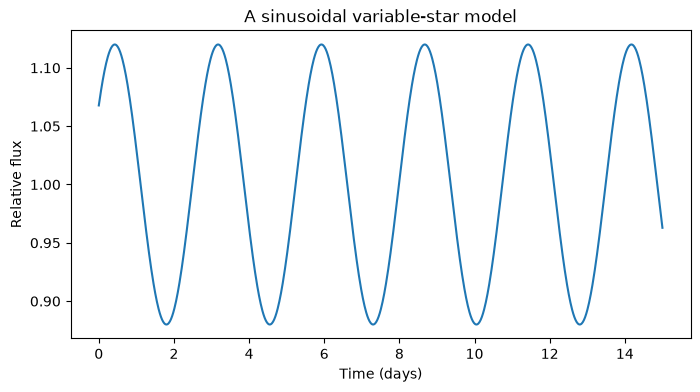

In [3]:
time_model = np.linspace(0, 15, 1000)  # days

model_flux = sinusoidal_light_curve(
    time_model,
    mean_flux=1.0,
    amplitude=0.12,
    period=2.75,
    phase=0.6,
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(time_model, model_flux)
ax.set(
    xlabel="Time (days)",
    ylabel="Relative flux",
    title="A sinusoidal variable-star model",
)
plt.show()

Relative flux is dimensionless here: the measurements have been divided by a reference flux. A value of 1.1 means the star is 10% brighter than that reference level.

### Exercise 1 — understand the model parameters

Plot several models while changing one parameter at a time.

1. Double the amplitude.
2. Change the period from 2.75 to 5 days.
3. Change the phase.
4. Increase the mean flux.

Describe what changes in each case. Which parameter changes the overall brightness without changing the variability pattern?

In [4]:
# Your code here

## 3. Create an unevenly sampled observation

Real monitoring rarely produces regularly spaced measurements. We simulate observations on eight nights, with several measurements during each night and gaps during the day. We then add Gaussian measurement noise.

In [5]:
rng = np.random.default_rng(42)

night_starts = np.array([0, 1, 2, 4, 5, 8, 11, 14])
time = np.sort(
    np.concatenate([
        night + rng.uniform(0.0, 0.28, 8)
        for night in night_starts
    ])
)

true_mean_flux = 1.0
true_amplitude = 0.12
true_period = 2.75  # days
true_phase = 0.6  # radians

flux_error = np.full(time.size, 0.02)
true_flux = sinusoidal_light_curve(
    time,
    true_mean_flux,
    true_amplitude,
    true_period,
    true_phase,
)
observed_flux = true_flux + rng.normal(0.0, flux_error)

print(f"Number of observations: {time.size}")
print(f"Time baseline: {np.ptp(time):.2f} days")

Number of observations: 64
Time baseline: 14.19 days


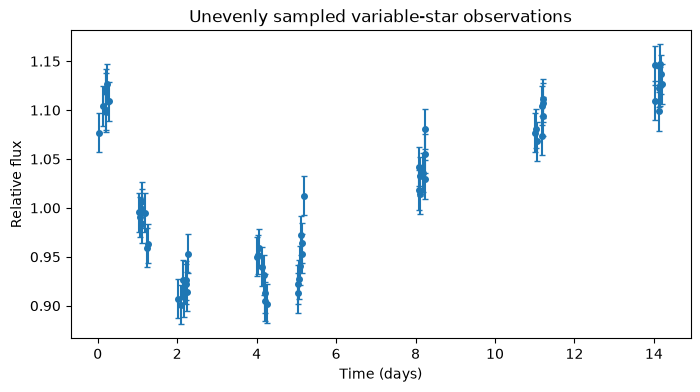

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(
    time,
    observed_flux,
    yerr=flux_error,
    fmt="o",
    markersize=4,
    capsize=2,
)
ax.set(
    xlabel="Time (days)",
    ylabel="Relative flux",
    title="Unevenly sampled variable-star observations",
)
plt.show()

Before fitting, inspect the sampling as well as the measured values. The gaps are part of the dataset and affect which periods can be recovered.

### Exercise 2 — inspect the light curve

Calculate the minimum, maximum, mean and standard deviation of `observed_flux`. Estimate the mean relative flux and variability amplitude by eye. Why is the standard deviation not the same thing as the sinusoidal semi-amplitude?

In [7]:
# Your code here

## 4. Fit the light curve when the period is approximately known

`curve_fit` varies the model parameters to minimise the weighted squared residuals. Non-linear fits need initial guesses. Here we suppose that an earlier study suggests a period near 2.7 days.

The bounds require a positive amplitude and period. Passing the measurement errors gives more influence to more precise observations, although all errors happen to be equal in this example.

In [8]:
initial_guess = [1.0, 0.1, 2.7, 0.0]

best_parameters, _ = curve_fit(
    sinusoidal_light_curve,
    time,
    observed_flux,
    p0=initial_guess,
    sigma=flux_error,
    absolute_sigma=True,
    bounds=(
        [0.0, 0.0, 0.2, -2 * np.pi],
        [2.0, 1.0, 20.0, 2 * np.pi],
    ),
)

mean_fit, amplitude_fit, period_fit, phase_fit = best_parameters

print(f"Mean relative flux = {mean_fit:.3f}")
print(f"Semi-amplitude     = {amplitude_fit:.3f}")
print(f"Period         = {period_fit:.4f} days")
print(f"Phase          = {phase_fit:.3f} rad")

Mean relative flux = 0.999
Semi-amplitude     = 0.127
Period         = 2.7633 days
Phase          = 0.617 rad


Evaluate the fitted model on a dense time grid for a smooth curve. Residuals are the observed values minus the model evaluated at the observation times.

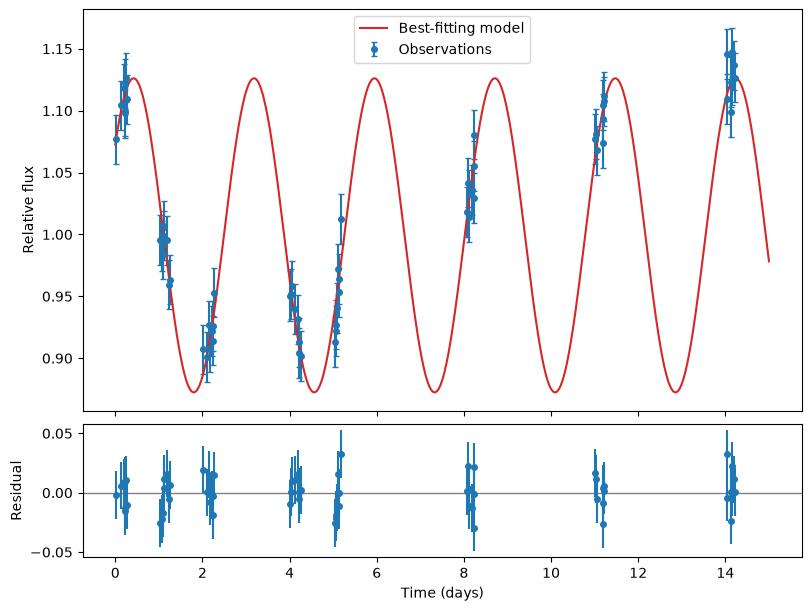

In [9]:
fitted_curve = sinusoidal_light_curve(time_model, *best_parameters)
fitted_at_data = sinusoidal_light_curve(time, *best_parameters)
residuals = observed_flux - fitted_at_data

fig, (ax, ax_res) = plt.subplots(
    2,
    1,
    figsize=(8, 6),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
    constrained_layout=True,
)

ax.errorbar(
    time,
    observed_flux,
    yerr=flux_error,
    fmt="o",
    markersize=4,
    capsize=2,
    label="Observations",
)
ax.plot(time_model, fitted_curve, color="tab:red", label="Best-fitting model")
ax.set_ylabel("Relative flux")
ax.legend()

ax_res.axhline(0, color="0.5", linewidth=1)
ax_res.errorbar(time, residuals, yerr=flux_error, fmt="o", markersize=4)
ax_res.set(xlabel="Time (days)", ylabel="Residual")

plt.show()

A useful fit should follow the repeated variability and leave residuals scattered around zero without a remaining periodic pattern. Always inspect the fit rather than relying only on its returned parameters.

### Exercise 3 — test the initial period

Repeat the fit with initial period guesses of 1, 2.5 and 5 days. Record the fitted period and inspect each model.

Do all starting values reach the same result? This illustrates why an independent period-search method is valuable for non-linear periodic models.

In [10]:
# Your code here

## 5. Search for an unknown period

The Lomb–Scargle periodogram tests sinusoidal variation over a range of frequencies and is designed for unevenly sampled data. We choose a scientifically plausible period range rather than asking the algorithm to search every possible frequency.

The `autopower()` method constructs a suitable grid of trial frequencies and calculates the Lomb–Scargle power at each one. A higher power indicates that a sinusoid at that frequency describes the observations more successfully.

Frequency and period are related by $P=1/f$. Because frequency increases from left to right while period decreases, we will plot the result against period and sort it into increasing order.

In [11]:
minimum_period = 0.5  # days
maximum_period = 10.0  # days

frequency, power = LombScargle(
    time,
    observed_flux,
    flux_error,
).autopower(
    minimum_frequency=1 / maximum_period,
    maximum_frequency=1 / minimum_period,
)

period = 1 / frequency
best_period = period[np.argmax(power)]

print(f"Highest-power period = {best_period:.4f} days")

Highest-power period = 2.7186 days


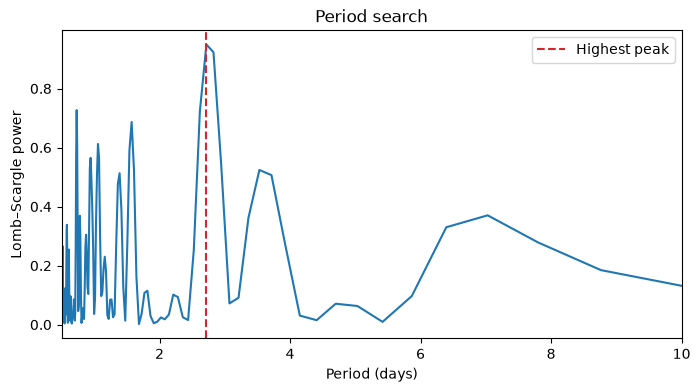

In [12]:
order = np.argsort(period)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(period[order], power[order])
ax.axvline(best_period, color="tab:red", linestyle="--", label="Highest peak")
ax.set(
    xlabel="Period (days)",
    ylabel="Lomb–Scargle power",
    title="Period search",
    xlim=(minimum_period, maximum_period),
)
ax.legend()
plt.show()

The tallest peak is the preferred sinusoidal period within the searched range. Other peaks can arise from the observing cadence and are often called aliases. A periodogram identifies candidate periods, but the corresponding light-curve model and residuals still need to be inspected.

## 6. Refine the model using the period search

Use the highest-power period as the initial value for `curve_fit`. This combines a broad period search with a direct fit of the physical parameters.

In [13]:
periodogram_guess = [
    np.mean(observed_flux),
    0.5 * np.ptp(observed_flux),
    best_period,
    0.0,
]

refined_parameters, _ = curve_fit(
    sinusoidal_light_curve,
    time,
    observed_flux,
    p0=periodogram_guess,
    sigma=flux_error,
    absolute_sigma=True,
    bounds=(
        [0.0, 0.0, minimum_period, -2 * np.pi],
        [2.0, 1.0, maximum_period, 2 * np.pi],
    ),
)

mean_refined, amplitude_refined, period_refined, phase_refined = refined_parameters

print(f"Periodogram period = {best_period:.4f} days")
print(f"Refined period     = {period_refined:.4f} days")
print(f"True period        = {true_period:.4f} days")

Periodogram period = 2.7186 days
Refined period     = 2.7633 days
True period        = 2.7500 days


## 7. Phase-fold the light curve

Observations separated by one period correspond to the same point in the variability cycle. The phase is the fractional part of time divided by period:

$$
\mathrm{phase} = \left(\frac{t}{P}\right) \bmod 1.
$$

Folding replaces observing time with phase, allowing repeated cycles to be viewed together.

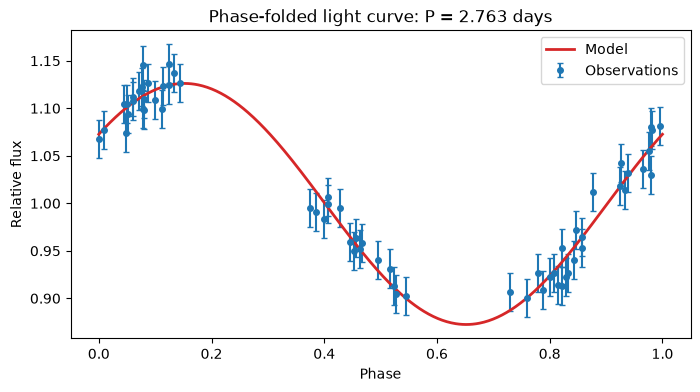

In [14]:
phase = (time / period_refined) % 1
phase_model = np.linspace(0, 1, 500)
time_one_cycle = phase_model * period_refined
folded_model = sinusoidal_light_curve(time_one_cycle, *refined_parameters)

fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(
    phase,
    observed_flux,
    yerr=flux_error,
    fmt="o",
    markersize=4,
    capsize=2,
    label="Observations",
)
ax.plot(phase_model, folded_model, color="tab:red", linewidth=2, label="Model")
ax.set(
    xlabel="Phase",
    ylabel="Relative flux",
    title=f"Phase-folded light curve: P = {period_refined:.3f} days",
)
ax.legend()
plt.show()

Phase folding is a visual test of the proposed period. If the period is appropriate, measurements from different cycles line up into a coherent pattern. A poor period causes the pattern to smear across phase.

### Exercise 4 — fold on an incorrect period

Repeat the phase-folded plot using a period of 2.5 days. Compare it with the plot using `period_refined`. Explain why a relatively small period error becomes obvious across a long observing baseline.

In [15]:
# Your code here

# Final Task: A new variable star

The cell below creates an independent, unevenly sampled light curve. Treat its variability parameters as unknown.

Your task is to:

1. plot the relative-flux observations with error bars
2. inspect the numerical range and observing cadence
3. use a Lomb–Scargle periodogram to search periods between 0.5 and 8 days
4. identify the highest-power candidate period
5. use that period to initialise a sinusoidal fit
6. plot the fitted model and residuals
7. phase-fold the light curve using the fitted period
8. report the mean relative flux, semi-amplitude and period
9. comment briefly on whether a sinusoid is an adequate model

Do not assume that the measurements are evenly spaced.

In [16]:
rng_final = np.random.default_rng(2026)

final_nights = np.array([0, 1, 3, 4, 7, 8, 12, 16, 17, 21])
time_final = np.sort(
    np.concatenate([
        night + rng_final.uniform(0.0, 0.3, 7)
        for night in final_nights
    ])
)

flux_error_final = rng_final.uniform(0.012, 0.025, time_final.size)

# Parameters used only to generate the independent dataset
hidden_flux = sinusoidal_light_curve(time_final, 1.0, 0.09, 3.42, -0.8)
observed_flux_final = hidden_flux + rng_final.normal(
    0.0, flux_error_final
)

In [17]:
# Final task workspace

# Start by plotting time_final against observed_flux_final.

# Assessment

You should be prepared to discuss your code for the final task during the viva for this lab. Bring a copy of this notebook with your completed analysis included.